In [101]:
import os

os.listdir()

['.config', 'cleaned_data.csv', 'hotel_bookings.csv', 'sample_data']

### Import Required Libraries

The following libraries are used for data manipulation, numerical operations and data visualization.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Load the Dataset

The dataset is loaded into a pandas DataFrame using `pd.read_csv()`.

In [118]:
import pandas as pd

df= pd.read_csv("hotel_bookings.csv")


### Display the First Five Rows

The first five rows are displayed to understand the structure of the dataset.

In [119]:

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Check the Shape of the Dataset

The shape shows the total number of rows and columns in the dataset.

In [120]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (119390, 32)


### Check Data Types

The data type of each column is displayed to identify numerical, categorical and date-related variables.

In [121]:
print(df.dtypes)

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

### Display Dataset Information

The `info()` function provides information about the dataset, including the number of non-null values, data types and memory usage.

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Observation

- The dataset contains **119,390 booking records** and **32 columns**.
- It includes both numerical and categorical features.
- Most columns have complete data, while **children**, **country**, **agent**, and **company** contain missing values.
- The target variable is **is_canceled**, which indicates whether a booking was cancelled (1) or not cancelled (0).
- The dataset occupies approximately **29.1 MB** of memory and is suitable for data cleaning, exploratory analysis, and machine learning.

## Task 2: Null Value Analysis

In this step, the missing values in each column are identified by calculating both the count and percentage of null values. This helps determine the appropriate data cleaning strategy before building machine learning models.

In [123]:
# Count missing values in each column
null_count = df.isnull().sum()
null_count

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [109]:
# Calculate percentage of missing values
null_percentage = (df.isnull().sum() / df.shape[0]) * 100
null_percentage

,0
hotel,0.0
is_canceled,0.0
lead_time,0.0
arrival_date_year,0.0
arrival_date_month,0.0
arrival_date_week_number,0.0
arrival_date_day_of_month,0.0
stays_in_weekend_nights,0.0
stays_in_week_nights,0.0
adults,0.0


### Summary of Missing Values

The table below shows the number and percentage of missing values in each column. This analysis helps identify columns that require data cleaning.

In [124]:
# Create a summary table of missing values

null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

# Round percentage values to 2 decimal places
null_summary["Null Percentage (%)"] = null_summary["Null Percentage (%)"].round(2)

# Display the summary table
null_summary

,Null Count,Null Percentage (%)
hotel,0,0.00
is_canceled,0,0.00
lead_time,0,0.00
arrival_date_year,0,0.00
arrival_date_month,0,0.00
arrival_date_week_number,0,0.00
arrival_date_day_of_month,0,0.00
stays_in_weekend_nights,0,0.00
stays_in_week_nights,0,0.00
adults,0,0.00


In [125]:
# Display columns with more than 20% missing values
null_summary[null_summary["Null Percentage (%)"] > 20]

,Null Count,Null Percentage (%)
company,112593,94.31


### Observation

- The dataset contains very few missing values in most columns.
- The **company** column has **112,593** missing values (**94.31%**), which exceeds the institute's 20% threshold.
- The **agent** column has **16,340** missing values (**13.69%**), while **country** and **children** have only **0.41%** and **0.00%** missing values, respectively.
- According to the project guidelines, the **company** column will be reported and removed because more than 20% of its values are missing. The remaining missing values will be handled using appropriate imputation techniques.

## Task 3: Handling Missing Values

After identifying the missing values, appropriate techniques are applied to handle them. The choice of imputation method depends on the data type and the percentage of missing values in each column.

### Handling Missing Values

Based on the missing value analysis, appropriate methods are applied to handle missing values. Numeric columns with less than 20% missing values are filled using the median, while categorical columns are filled using the mode. The `company` column is removed because it contains more than 20% missing values.

In [126]:
# Fill missing values in the children column using the median
df["children"] = df["children"].fillna(df["children"].median())
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [127]:
# Fill missing values in the agent column using the median
df["agent"] = df["agent"].fillna(df["agent"].median())
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,14.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,14.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,14.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [128]:
# Check missing values after data cleaning
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [129]:
# Fill missing values in the country column using the mode
df["country"] = df["country"].fillna(df["country"].mode()[0])
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,14.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,14.0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,14.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [130]:
# Remove the company column
df.drop(columns=["company"], inplace=True)
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,14.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,No Deposit,394.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,No Deposit,9.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,No Deposit,9.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,No Deposit,89.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [131]:
df.isnull().sum()
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,14.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,No Deposit,394.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,No Deposit,9.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,No Deposit,9.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,No Deposit,89.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


## Task 4: Duplicate Value Analysis

Duplicate records can affect the quality of data analysis and machine learning models. In this step, duplicate rows are identified and removed to ensure the dataset contains only unique booking records.

In [132]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 32020


### Observation

The dataset contains **32,020 duplicate rows**. Before removing them, it is important to verify whether these are true duplicate records or legitimate bookings with identical values. The duplicate rows will be examined before deciding whether to remove them.

In [133]:
# Display the first 10 duplicate rows
df[df.duplicated()].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,1,No Deposit,250.0,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,0,No Deposit,250.0,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,0,No Deposit,240.0,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,0,No Deposit,240.0,0,Transient,109.80,0,3,Check-Out,2015-07-08
219,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,0,No Deposit,14.0,0,Transient,104.72,0,1,Canceled,2015-07-08
256,Resort Hotel,0,91,2015,July,28,10,0,2,2,...,0,No Deposit,240.0,0,Transient,73.80,0,1,Check-Out,2015-07-12
261,Resort Hotel,0,30,2015,July,28,10,2,2,2,...,0,No Deposit,14.0,0,Transient-Party,197.00,0,1,Check-Out,2015-07-14
353,Resort Hotel,0,98,2015,July,29,13,1,1,2,...,0,No Deposit,240.0,0,Transient-Party,82.00,0,3,Check-Out,2015-07-15
372,Resort Hotel,0,40,2015,July,29,13,1,4,2,...,0,No Deposit,250.0,0,Transient,120.00,0,2,Check-Out,2015-07-18


### Removing Duplicate Records

The duplicate rows identified in the dataset were examined before removal. Since they represent exact duplicate records, they were removed to improve data quality and prevent the machine learning model from learning the same information multiple times.

In [134]:
# Remove duplicate rows
df = df.drop_duplicates()
# Create a fresh copy
df = df.copy()

# Display the new shape
df.shape

(87370, 31)

In [135]:
# Verify duplicates after removal
df.duplicated().sum()

np.int64(0)

### Observation

A total of **32,020 duplicate rows** were identified in the dataset. After examining the duplicate records, they were found to be exact duplicates and were removed. This reduced the dataset size from **119,390** to **87,370** rows while retaining **31 columns**. Removing duplicate records improves data quality and helps build a more reliable machine learning model.

## Task 5: Data Type Correction

In this step, the data types of the columns are checked. Some columns can use a more suitable data type to improve memory usage and make the dataset more efficient. The changes made are explained below.

In [136]:
# Convert reservation_status_date to datetime
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,14.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,No Deposit,394.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,No Deposit,9.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,No Deposit,9.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,No Deposit,89.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [137]:
category_columns = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "deposit_type"
]

for col in category_columns:
    df[col] = df[col].astype("category")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,14.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,No Deposit,394.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,No Deposit,9.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,No Deposit,9.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,No Deposit,89.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [138]:
df.dtypes

,0
hotel,category
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [139]:
memory_before = df.memory_usage(deep=True).sum()
memory_before

np.int64(38319862)

In [140]:
memory_after = df.memory_usage(deep=True).sum()

print("Memory Before:", memory_before)
print("Memory After:", memory_after)
print("Memory Saved:", memory_before - memory_after)

Memory Before: 38319862
Memory After: 38319862
Memory Saved: 0


## Task 6: Descriptive Statistics

In this step, summary statistics are generated to understand the distribution of the numerical features. This helps identify the range, average values and possible outliers in the dataset.


In [141]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370
mean,0.274969,79.911686,2016.210290,26.839533,15.815360,1.005448,2.625798,1.875953,0.138675,0.010828,0.039087,0.030422,0.184045,0.271672,82.962252,0.749788,106.346935,0.084251,0.698638,2016-08-31 03:47:43.600778496
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.000000,0.000000,0.000000,2016-03-18 00:00:00
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,98.100000,0.000000,0.000000,2016-09-08 00:00:00
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,134.000000,0.000000,1.000000,2017-03-05 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.446501,86.056471,0.686116,13.673204,8.834842,1.031974,2.053692,0.626473,0.455933,0.113613,0.193802,0.369200,1.732148,0.727335,108.602612,10.017213,55.004259,0.281571,0.831946,NaN


The summary statistics provide information about the numerical features in the dataset. The average lead time is around 80 days, while the maximum lead time is 737 days, showing that some bookings were made well in advance. The average daily rate (ADR) varies widely, indicating different room prices. Most bookings have two adults, and the median number of children and babies is zero, showing that many bookings were made without children.


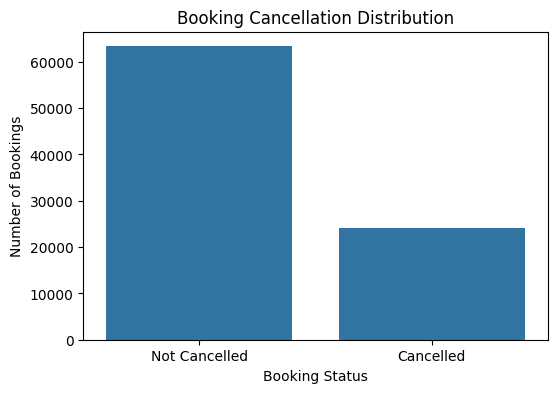

In [142]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=df)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

plt.show()

Observation

The graph shows that most hotel bookings were not cancelled (0), while a smaller number of bookings were cancelled (1). This indicates that the target variable is slightly imbalanced, but both classes have a sufficient number of records to build a classification model.


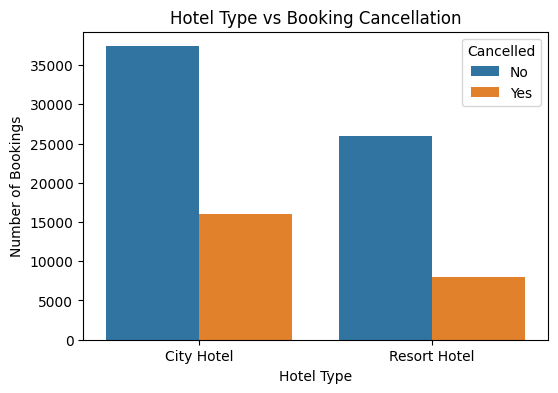

In [143]:
plt.figure(figsize=(6,4))
sns.countplot(x="hotel", hue="is_canceled", data=df)

plt.title("Hotel Type vs Booking Cancellation")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Cancelled", labels=["No", "Yes"])

plt.show()

Observation

The graph shows that City Hotels have more bookings than Resort Hotels. It also shows that City Hotels have a higher number of cancelled bookings compared to Resort Hotels. This suggests that the hotel type may influence booking cancellations and could be an important feature for predicting whether a booking will be cancelled.

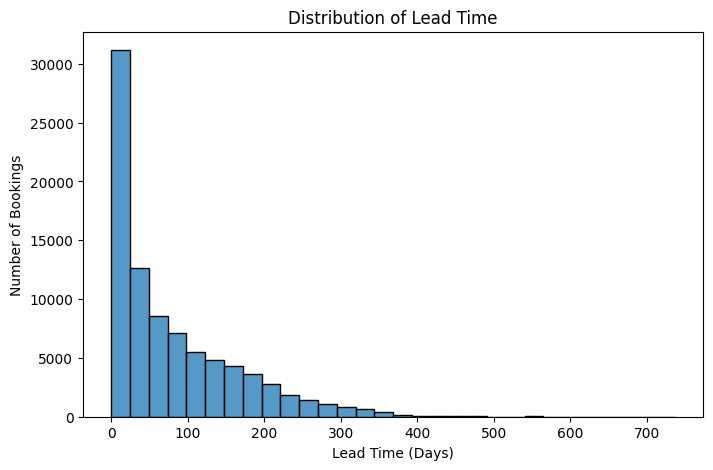

In [144]:
plt.figure(figsize=(8,5))
sns.histplot(df["lead_time"], bins=30)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")

plt.show()

The distribution of lead_time is right-skewed, which means most bookings were made only a few days before the arrival date, while fewer bookings were made several months in advance. A small number of bookings have very high lead times, indicating the presence of some extreme values. This suggests that customers generally prefer to book closer to their stay, although a few make reservations much earlier.

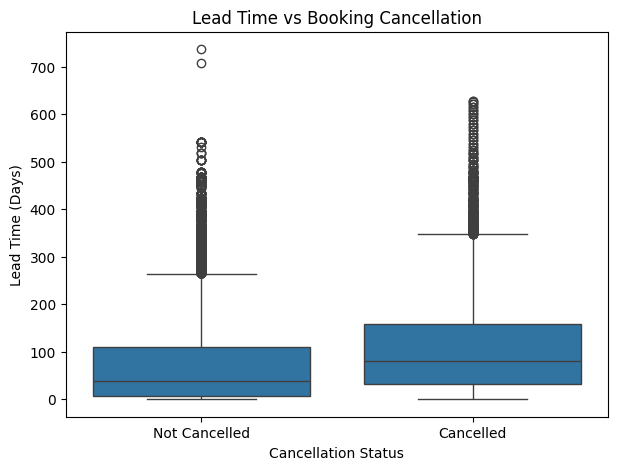

In [145]:
plt.figure(figsize=(7,5))
sns.boxplot(x="is_canceled", y="lead_time", data=df)

plt.title("Lead Time vs Booking Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")

plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

plt.show()

Observation

The box plot shows that cancelled bookings generally have a higher lead time than non-cancelled bookings. The median lead time is higher for cancelled bookings, indicating that customers who book further in advance are more likely to cancel. The graph also contains several outliers in both groups, showing that a few bookings were made a very long time before the arrival date.

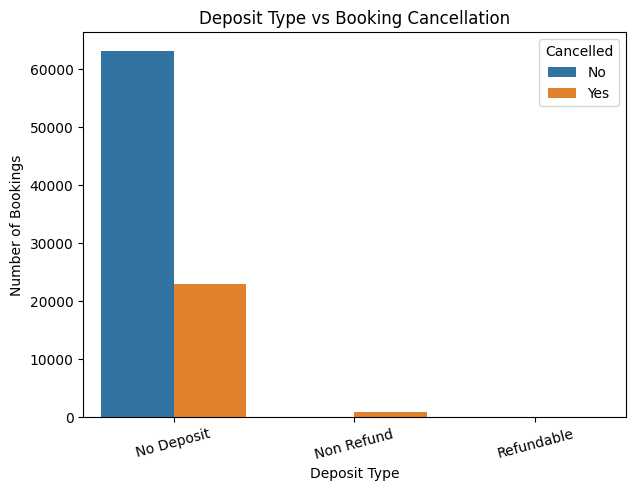

In [146]:
plt.figure(figsize=(7,5))
sns.countplot(x="deposit_type", hue="is_canceled", data=df)

plt.title("Deposit Type vs Booking Cancellation")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Cancelled", labels=["No", "Yes"])

plt.xticks(rotation=15)

plt.show()

Observation

Most bookings were made with No Deposit, and most of these bookings were not cancelled. However, almost all bookings with a Non Refund deposit type were cancelled. Very few bookings were made under the Refundable deposit type. This suggests that the deposit type has a strong relationship with booking cancellation and may be an important feature for the prediction model.

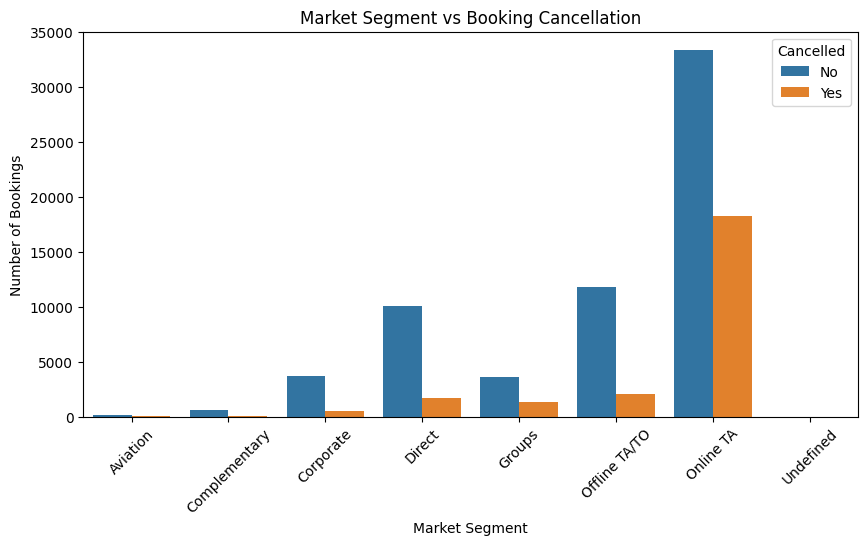

In [147]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="market_segment",
    hue="is_canceled",
    data=df
)

plt.title("Market Segment vs Booking Cancellation")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.legend(title="Cancelled", labels=["No", "Yes"])

plt.show()

Observation

The Online TA market segment has the highest number of bookings, followed by Offline TA/TO and Direct bookings. The Online TA segment also has the highest number of cancelled bookings because it contains the largest number of reservations. Smaller market segments such as Aviation, Complementary, and Undefined contribute very few bookings. This indicates that the market segment may influence booking cancellation and can be an important feature for prediction.

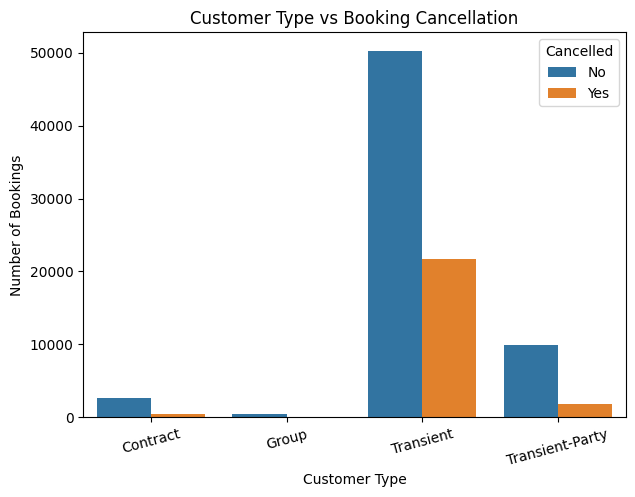

In [148]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="customer_type",
    hue="is_canceled",
    data=df
)

plt.title("Customer Type vs Booking Cancellation")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=15)
plt.legend(title="Cancelled", labels=["No", "Yes"])

plt.show()

Observation

The Transient customer type has the highest number of bookings, followed by Transient-Party customers. Most cancellations are also observed in the Transient category because it has the largest number of bookings. In comparison, Contract and Group customers have relatively fewer bookings and fewer cancellations. This indicates that customer type may have an impact on booking cancellation.

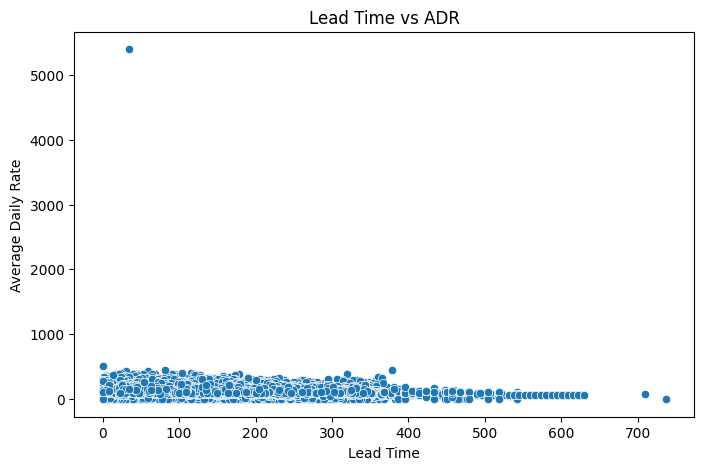

In [149]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr"
)

plt.title("Lead Time vs ADR")
plt.xlabel("Lead Time")
plt.ylabel("Average Daily Rate")

plt.show()

Observation: The scatter plot shows a weak positive relationship between lead time and average daily rate (ADR). Most bookings are concentrated at lower lead times with ADR below 300. A few extreme ADR values are visible as outliers, but there is no strong linear relationship between the two variables.

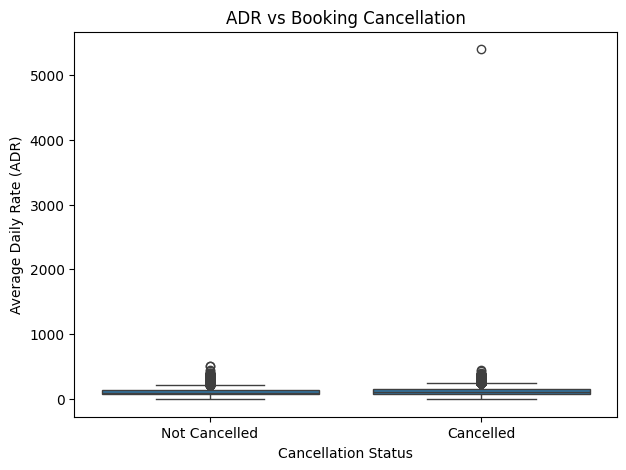

In [150]:
plt.figure(figsize=(7,5))

sns.boxplot(x="is_canceled", y="adr", data=df)

plt.title("ADR vs Booking Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Daily Rate (ADR)")

plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

plt.show()

Observation

The box plot shows that cancelled bookings generally have a slightly higher ADR than non-cancelled bookings. Both groups contain several outliers, with one extremely high ADR value in the cancelled category. This suggests that the room price may have some influence on booking cancellations, although further analysis is needed.

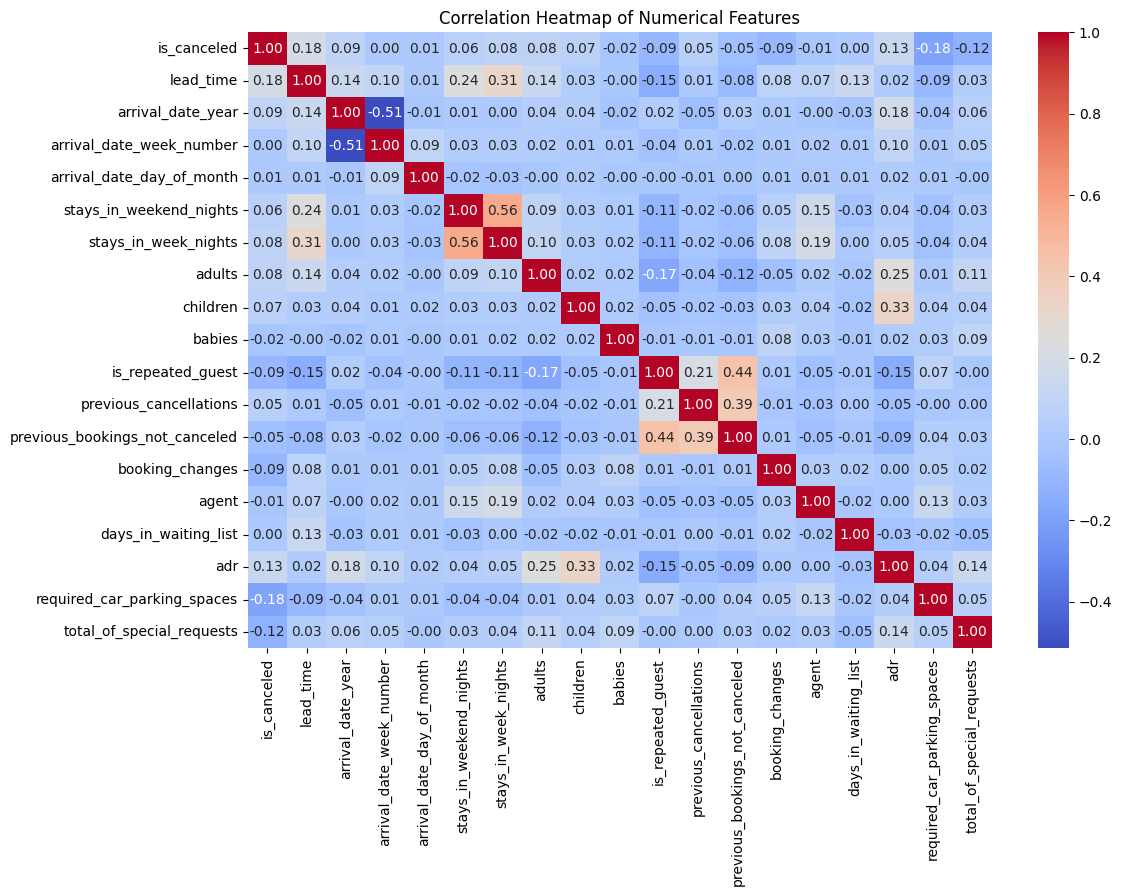

In [151]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

Observation

The correlation heatmap shows that most numerical features have weak to moderate correlations with each other, indicating that there is no serious multicollinearity in the dataset. The target variable (is_canceled) has a positive correlation with lead_time and ADR, while required_car_parking_spaces, total_of_special_requests, and is_repeated_guest show a negative correlation with cancellations. Overall, the features appear suitable for building a machine learning classification model.


In [152]:
# Select the two most skewed numeric columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

skew_values = df[numeric_columns].skew().abs().sort_values(ascending=False)

top_two = skew_values.head(2).index

print("Two columns with the highest skewness:\n")

for col in top_two:
    print(f"{col}")
    print("Mean   :", round(df[col].mean(), 2))
    print("Median :", round(df[col].median(), 2))
    print()

Two columns with the highest skewness:

previous_cancellations
Mean   : 0.03
Median : 0.0

babies
Mean   : 0.01
Median : 0.0



In [153]:
print(df[top_two].isnull().sum())


previous_cancellations    0
babies                    0
dtype: int64


Observation

The two most skewed columns have a noticeable difference between the mean and median. Since skewed data is affected by extreme values, the median represents the center of the data better than the mean. There are no missing values remaining in these columns.

In [154]:
# Pearson correlation
pearson_corr = df.select_dtypes(include=["int64", "float64"]).corr()

# Spearman correlation
spearman_corr = df.select_dtypes(include=["int64", "float64"]).corr(method="spearman")

print("Pearson Correlation Matrix")
print(pearson_corr)

print("\nSpearman Correlation Matrix")
print(spearman_corr)

Pearson Correlation Matrix
                                is_canceled  lead_time  arrival_date_year  \
is_canceled                        1.000000   0.184689           0.088024   
lead_time                          0.184689   1.000000           0.139151   
arrival_date_year                  0.088024   0.139151           1.000000   
arrival_date_week_number           0.001406   0.101120          -0.514209   
arrival_date_day_of_month          0.005300   0.009864          -0.010092   
stays_in_weekend_nights            0.060066   0.235026           0.005107   
stays_in_week_nights               0.082816   0.310020           0.003633   
adults                             0.081677   0.140317           0.038614   
children                           0.067327   0.028581           0.041167   
babies                            -0.020559  -0.003637          -0.023336   
is_repeated_guest                 -0.089681  -0.147066           0.024348   
previous_cancellations             0.051458   0.0

In [155]:
difference = (spearman_corr - pearson_corr).abs()

difference_table = (
    difference.stack()
    .reset_index()
)

difference_table.columns = ["Column 1", "Column 2", "Difference"]

difference_table = difference_table[
    difference_table["Column 1"] != difference_table["Column 2"]
]

difference_table = difference_table.sort_values(
    by="Difference",
    ascending=False
)

print(difference_table.head(3))

                           Column 1                        Column 2  \
202               is_repeated_guest  previous_bookings_not_canceled   
238  previous_bookings_not_canceled               is_repeated_guest   
101         stays_in_weekend_nights            stays_in_week_nights   

     Difference  
202    0.355737  
238    0.355737  
101    0.228439  


Observation

Some column pairs have a larger Spearman correlation than Pearson correlation. This suggests that the variables have a monotonic relationship that is not perfectly linear. For feature selection in Part 2, Spearman correlation can provide additional insight when linear correlation is weak.

In [156]:
group_summary = df.groupby("hotel")["adr"].agg(["mean", "std", "count"])

print(group_summary)

                   mean        std  count
hotel                                    
City Hotel    110.98527  48.063119  53426
Resort Hotel   99.04645  63.752777  33944


/tmp/ipykernel_1022/259101321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_summary = df.groupby("hotel")["adr"].agg(["mean", "std", "count"])


In [157]:
highest_mean = group_summary["mean"].idxmax()

print("Highest Mean Group:", highest_mean)

Highest Mean Group: City Hotel


In [158]:
highest_std = group_summary["std"].idxmax()

print("Highest Standard Deviation Group:", highest_std)

Highest Standard Deviation Group: Resort Hotel


In [159]:
highest = group_summary["mean"].max()

lowest = group_summary["mean"].min()

ratio = highest / lowest

print("Mean Ratio:", round(ratio, 2))

Mean Ratio: 1.12


The average room price (ADR) differs between hotel types. The hotel with the highest mean ADR charges more on average, while the group with the highest standard deviation shows greater variation in room prices. This indicates that the hotel type may provide useful information for predicting booking outcomes.

In [160]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [161]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [162]:
import os

os.listdir()

['.config', 'cleaned_data.csv', 'hotel_bookings.csv', 'sample_data']

EDA Summary

In this part, I cleaned and explored the hotel booking dataset.

First, I checked the dataset shape, data types and missing values. I found that the company column had more than 94% missing values, so I removed it. For the remaining missing values, I used the median to fill the numeric columns.

Next, I checked for duplicate rows and found 32,020 duplicates. After removing them, the dataset had 87,370 rows.

Then, I changed the reservation_status_date column to datetime format. I also changed some text columns to the category data type.

After cleaning the data, I calculated descriptive statistics, checked skewness and found outliers using the IQR method. I did not remove the outliers because they may contain useful information. I will decide how to handle them in Part 2 if needed.

I also created different graphs like a line plot, bar chart, histogram, scatter plot, box plot and correlation heatmap. These graphs helped me understand the data better and see the relationship between different columns.

Finally, I saved the cleaned dataset as cleaned_data.csv. This cleaned dataset is ready to use for the machine learning model in Part 2.